In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('C:\\projects\\MindMirror AI\\Dataset\\fer2013.csv')
print(df.head(5))


   emotion                                             pixels     Usage
0        0  70 80 82 72 58 58 60 63 54 58 60 48 89 115 121...  Training
1        0  151 150 147 155 148 133 111 140 170 174 182 15...  Training
2        2  231 212 156 164 174 138 161 173 182 200 106 38...  Training
3        4  24 32 36 30 32 23 19 20 30 41 21 22 32 34 21 1...  Training
4        6  4 0 0 0 0 0 0 0 0 0 0 0 3 15 23 28 48 50 58 84...  Training


In [4]:
pixels = df.loc[0, "pixels"]

pixel_array = np.array(pixels.split(), dtype="float32")


Now the computer understands them as numbers


In [5]:
print(pixel_array.shape)

(2304,)


Reshape into an Image,
Currently:(2034,) => it is 1D array

In [6]:
image = pixel_array.reshape(48,48)

In [7]:
print(image.shape)

(48, 48)


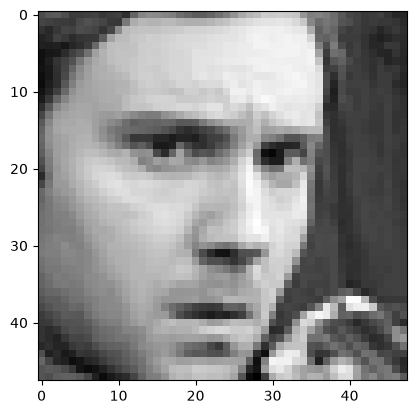

In [8]:
plt.imshow(image, cmap="gray")
plt.show()

Read Every Image , convert all images.

In [9]:
X=[]
for i in df["pixels"]:
    image=np.array(i.split(),dtype="float32")
    image=image.reshape(48,48)
    X.append(image)

X=np.array(X)

(35887, 48, 48)
[[ 70.  80.  82. ...  52.  43.  41.]
 [ 65.  61.  58. ...  56.  52.  44.]
 [ 50.  43.  54. ...  49.  56.  47.]
 ...
 [ 91.  65.  42. ...  72.  56.  43.]
 [ 77.  82.  79. ... 105.  70.  46.]
 [ 77.  72.  84. ... 106. 109.  82.]]


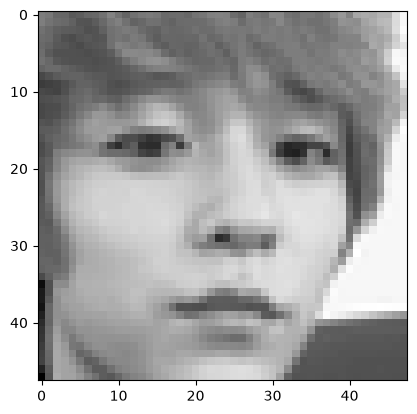

In [10]:
print(X.shape)
print(X[0])
plt.imshow(X[13], cmap="gray")
plt.show()

In [11]:
y=df["emotion"]

In [12]:
X = X / 255.0

In [13]:
X=X.reshape(-1,48,48,1)

In [14]:
print(X.shape)
print(y.shape)

(35887, 48, 48, 1)
(35887,)


In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [16]:
from tensorflow.keras.utils import to_categorical
y_train=to_categorical(y_train,num_classes=7)
y_test=to_categorical(y_test,num_classes=7)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,Flatten,Dropout,MaxPooling2D
model=Sequential()
model.add(Conv2D(filters=32,kernel_size=(3,3),activation="relu",input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation="relu",input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(filters=128,kernel_size=(3,3),activation="relu",input_shape=(48,48,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=128,activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(units=7,activation="softmax"))
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])
model.summary()
history=model.fit(X_train,y_train,epochs=10,batch_size=10,validation_split=0.2)


c:\Users\mrgnk\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 31s 12ms/step - accuracy: 0.2887 - loss: 1.7468 - val_accuracy: 0.3798 - val_loss: 1.5664
Epoch 2/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.4031 - loss: 1.5334 - val_accuracy: 0.4646 - val_loss: 1.4133
Epoch 3/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.4538 - loss: 1.4141 - val_accuracy: 0.5040 - val_loss: 1.3239
Epoch 4/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.4845 - loss: 1.3416 - val_accuracy: 0.5035 - val_loss: 1.2950
Epoch 5/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.5031 - loss: 1.2863 - val_accuracy: 0.5183 - val_loss: 1.2542
Epoch 6/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 27s 12ms/step - accuracy: 0.5239 - loss: 1.2383 - val_accuracy: 0.5266 - val_loss: 1.2483
Epoch 7/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 28s 12ms/step - accuracy: 0.5393 - loss: 1.1982 - val_accuracy: 0.5394 - val_loss: 1.2171
Epoch 8/10
2297/2297 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.5539 -

In [18]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)
print("Training Loss:",history.history['loss'][-1])
print("Training Accuracy:",history.history["accuracy"][-1])
print("Validation Loss:",history.history['val_loss'][-1])
print("Validation Accuracy:",history.history['val_accuracy'][-1])


225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5382 - loss: 1.2346
Test Loss: 1.2346041202545166
Test Accuracy: 0.53817218542099
Training Loss: 1.094748616218567
Training Accuracy: 0.5768711566925049
Validation Loss: 1.2253097295761108
Validation Accuracy: 0.5397074222564697


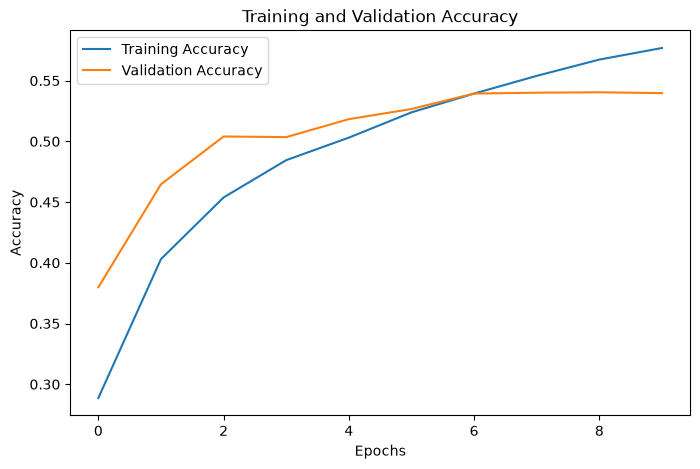

In [19]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")    
plt.ylabel("Accuracy")
plt.legend()
plt.show()

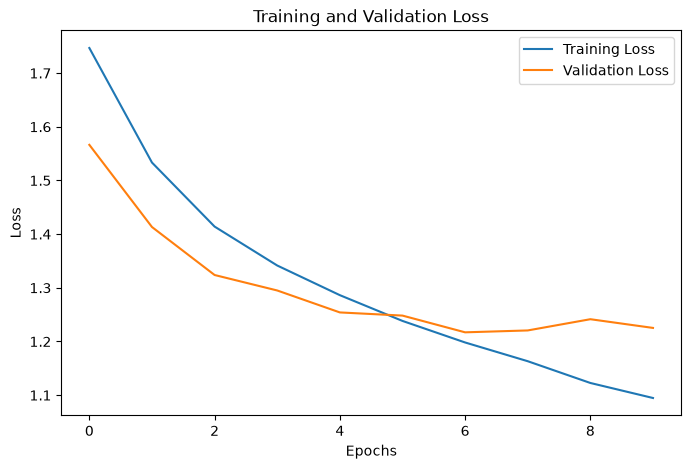

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Training and Validation Loss")
plt.xlabel("Epochs")    
plt.ylabel("Loss")
plt.legend()
plt.show()